# Sinusoidal Synthesis Example

This notebook shows how sinusoidal synthesis works using the SMS-tools functions `genSpecSines` and `sineModelSynth`:

1. Define sinusoidal frequencies, magnitudes, and phases by hand.
2. Generate one complex spectrum with `utilFunctions.genSpecSines`.
3. Visualize the magnitude spectrum, phase spectrum, and the corresponding synthesized frame.
4. Build time-varying track matrices and synthesize a longer signal with `sineModelSynth`.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
from scipy.fft import fftshift, ifft
from scipy.signal import get_window
from smstools.models import utilFunctions as UF
from smstools.models import sineModel as SM
import plot_helpers as PH

PH.setup_plot_style()
eps = np.finfo(float).eps

## 2) Define sinusoidal parameters

We start from three sinusoids defined directly in Hertz, linear amplitudes, and radians.

`genSpecSines` expects magnitudes in dB, so we convert the linear amplitudes with `20 * log10(amplitude / 2)`, matching the SMS-tools sinusoidal synthesis convention used in the lecture examples.

In [10]:
fs = 44100
duration = 1.0
frequencies = np.array([200.0, 880.0, 1320.0])
amplitudes = np.array([0.8, 0.4, 0.25])
initial_phases = np.array([0.0, 1.1, 2.2])
Ns = 512
H = Ns // 4
magnitudes_db = 20 * np.log10(amplitudes / 2.0)

print('Sampling rate:', fs)
print('Synthesis FFT size (Ns):', Ns)
print('Hop size (H):', H)
print('Frequencies (Hz):', frequencies)
print('Amplitudes:', amplitudes)
print('Initial phases (rad):', initial_phases)
print('Magnitudes for genSpecSines (dB):', np.round(magnitudes_db, 2))

Sampling rate: 44100
Synthesis FFT size (Ns): 512
Hop size (H): 128
Frequencies (Hz): [ 200.  880. 1320.]
Amplitudes: [0.8  0.4  0.25]
Initial phases (rad): [0.  1.1 2.2]
Magnitudes for genSpecSines (dB): [ -7.96 -13.98 -18.06]


## 3) Generate one spectral frame with `genSpecSines`

A single call to `genSpecSines` creates one complex spectrum from the sinusoidal frequencies, magnitudes, and phases.

From that complex spectrum we plot:

1. The magnitude spectrum.
2. The phase spectrum.
3. The time-domain frame obtained by inverse FFT.

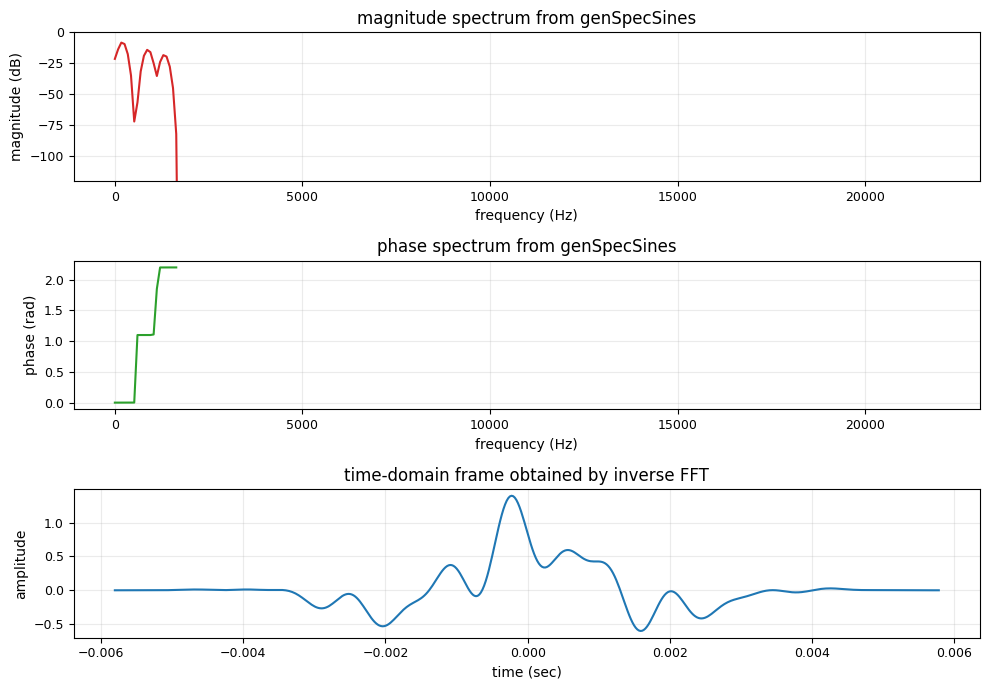

In [11]:
Y = UF.genSpecSines(frequencies, magnitudes_db, initial_phases, Ns, fs)
hNs = Ns // 2
positive_spectrum = Y[:hNs]
magnitude_linear = np.abs(positive_spectrum)
magnitude_linear[magnitude_linear < eps] = eps
magnitude_spectrum = 20 * np.log10(magnitude_linear)
phase_spectrum = np.unwrap(np.angle(positive_spectrum))
phase_spectrum[magnitude_spectrum < -100] = np.nan
frame_signal = fftshift(np.real(ifft(Y))) * np.sum(get_window('blackmanharris', Ns))
freq_axis = fs * np.arange(hNs) / float(Ns)
time_axis = np.arange(-hNs, hNs) / float(fs)

fig, axes = plt.subplots(3, 1, figsize=(10, 7))
PH.plot_spectrum(axes[0], freq_axis, magnitude_spectrum, title='magnitude spectrum from genSpecSines', color='tab:red')
axes[0].set_ylim([-120, 0])
axes[0].grid(alpha=0.25)
# Align phase plot x-axis with magnitude plot
axes[1].plot(freq_axis, phase_spectrum, color='tab:green', linewidth=1.5)
axes[1].set_title('phase spectrum from genSpecSines')
axes[1].set_xlabel('frequency (Hz)')
axes[1].set_ylabel('phase (rad)')
axes[1].set_xlim(axes[0].get_xlim())  # Ensure same frequency axis as magnitude
axes[1].grid(alpha=0.25)
axes[2].plot(time_axis, frame_signal, color='tab:blue', linewidth=1.5)
axes[2].set_title('time-domain frame obtained by inverse FFT')
axes[2].set_xlabel('time (sec)')
axes[2].set_ylabel('amplitude')
axes[2].grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 4) Generate a longer time signal with `sineModelSynth`

`sineModelSynth` expects one frequency, magnitude, and phase vector per frame.

To synthesize a stationary tone lasting one second, we repeat the same frequencies and magnitudes in all frames, and we propagate the phases from frame to frame so that the synthesized waveform is phase-consistent across time.

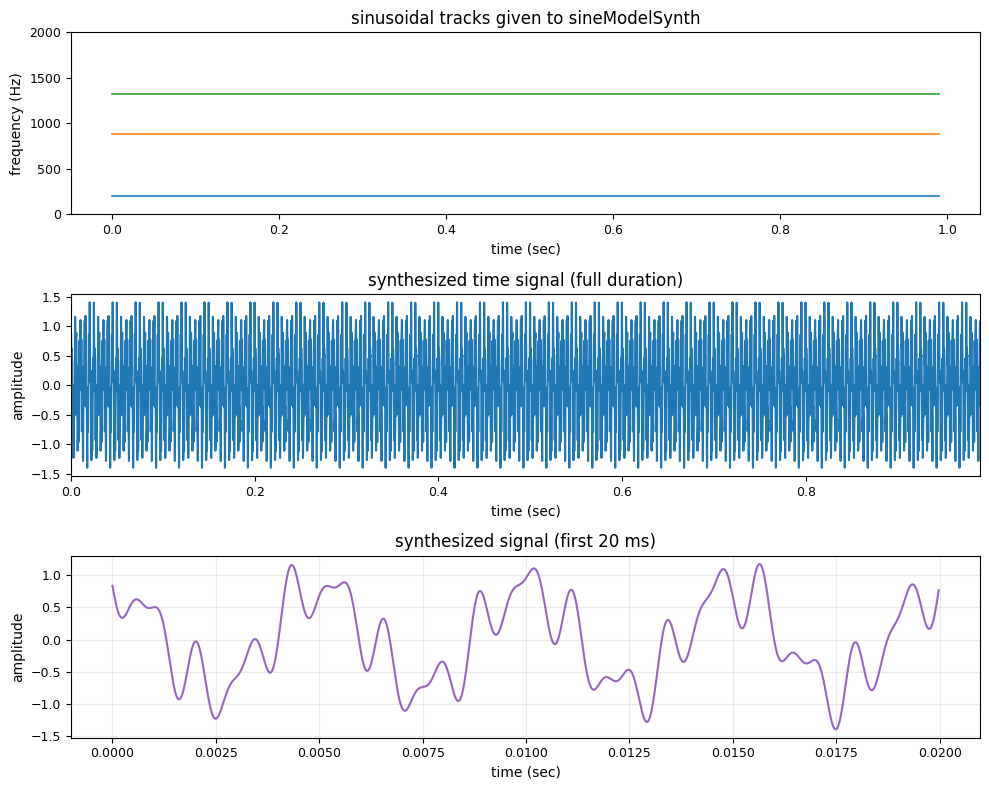

In [12]:
duration_samples = int(duration * fs)
num_frames = max(1, int(np.ceil((duration_samples - Ns) / float(H))) + 1)
frame_times = np.arange(num_frames) * H / float(fs)
tfreq = np.tile(frequencies, (num_frames, 1))
tmag = np.tile(magnitudes_db, (num_frames, 1))
tphase = (initial_phases[np.newaxis, :] + 2 * np.pi * frame_times[:, np.newaxis] * frequencies[np.newaxis, :]) % (2 * np.pi)
y = SM.sineModelSynth(tfreq, tmag, tphase, Ns, H, fs)
y = y[:duration_samples]

fig, axes = plt.subplots(3, 1, figsize=(10, 8))
PH.plot_frequency_tracks(axes[0], tfreq, fs, H, title='sinusoidal tracks given to sineModelSynth', max_freq=2000, linewidth=1.2)
PH.plot_waveform(axes[1], y, fs, title='synthesized time signal (full duration)')
zoom_samples = int(0.02 * fs)
axes[2].plot(np.arange(zoom_samples) / float(fs), y[:zoom_samples], color='tab:purple', linewidth=1.5)
axes[2].set_title('synthesized signal (first 20 ms)')
axes[2].set_xlabel('time (sec)')
axes[2].set_ylabel('amplitude')
axes[2].grid(alpha=0.25)
plt.tight_layout()
plt.show()

ipd.display(ipd.Audio(data=y, rate=fs))